<a href="https://colab.research.google.com/github/EpiccSafe-Capstone/epicc-safe-system/blob/main/Capstone_Project_ML_(versi_1_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EpiccSafe — Deteksi Phishing Bank CIMB

## Dataset
- **Dataset:** [PhiUSIIL Phishing URL Dataset](https://www.kaggle.com/datasets/ndarvind/phiusiil-phishing-url-dataset)

### Penjelasan dataset
PhiUSIIL Phishing URL Dataset berisi 235.795 URL (134.850 legitimate + 100.945 phishing) yang dikumpulkan langsung dari webpage yang diunduh. Fitur diekstrak dari source code HTML dan struktur URL. Dataset ini difokuskan untuk mendeteksi serangan berbasis kemiripan visual seperti zero-width characters, homograph, punycode, homophone, bitsquatting, dan combosquatting.

### Alur pipeline
```
  Dataset (PhiUSIIL)
       ↓
  Data Cleaning
       ↓
  Train/Test Split (80:20, stratified)
       ↓
  Training Model  →  Validation Set (20%)
       ↓
  Risk Scoring + Evaluasi Final
```

## Data Cleaning

Alur Pipeline
```
Load Data → Inspeksi Awal → Hapus Duplikat → Tangani Missing Values
→ Validasi Format URL → Normalisasi Label → Deteksi Outlier
→ Feature Selection → Tangani Class Imbalance (SMOTE)
→ Normalisasi Fitur (MinMaxScaler) → Simpan Data Bersih
```

In [2]:
!pip install pandas numpy scikit-learn imbalanced-learn tldextract matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 2.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
!pip install tldextract -q
import tldextract
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


### Load dataset

In [4]:
!pip install kagglehub[pandas-datasets] -q

In [5]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

# Set the path to the file you'd like to load
file_path = "PhiUSIIL_Phishing_URL_Dataset.csv"

# Load the latest version
df_phi = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ndarvind/phiusiil-phishing-url-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df_phi.head())

100%|██████████| 14.7M/14.7M [00:00<00:00, 28.4MB/s]

Extracting zip of PhiUSIIL_Phishing_URL_Dataset.csv...


First 5 records:                                   URL  URLLength                      Domain  \
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com   
1            https://www.uni-mainz.de         23            www.uni-mainz.de   
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk   
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com   
4  https://www.rewildingargentina.org         33  www.rewildingargentina.org   

   DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  \
0            24           0  com               100.0              1.000000   
1            16           0   de               100.0              0.666667   
2            22           0   uk               100.0              0.866667   
3            19           0  com               100.0              1.000000   
4            26           0  org               100.0              1.000000   

   TLDLegitimateProb  URLCharProb

In [6]:
print('=== PhiUSIIL Dataset ===')
print(f'Shape  : {df_phi.shape}')
print(f'Kolom  : {list(df_phi.columns)}')
print(f'\nDistribusi label (sebelum normalisasi):')
print(df_phi['label'].value_counts())
df_phi.head(3)

=== PhiUSIIL Dataset ===
Shape  : (235795, 55)
Kolom  : ['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

Distribusi label (sebelum normalisas

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1


### Mengechek isi dataset

In [7]:
def inspeksi_dataset(df, nama):
    print(f'\n{"="*50}')
    print(f'INSPEKSI: {nama}')
    print(f'{"="*50}')
    print(f'Jumlah baris   : {len(df):,}')
    print(f'Jumlah kolom   : {df.shape[1]}')
    print(f'Duplikat       : {df.duplicated().sum():,}')
    print(f'\nMissing values per kolom (hanya yang ada nilai kosong):')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        print('  → Tidak ada missing values!')
    else:
        print(missing)
    print(f'\nStatistik deskriptif (numerik):')
    print(df.describe())

inspeksi_dataset(df_phi, 'PhiUSIIL')


INSPEKSI: PhiUSIIL
Jumlah baris   : 235,795
Jumlah kolom   : 55
Duplikat       : 0

Missing values per kolom (hanya yang ada nilai kosong):
  → Tidak ada missing values!

Statistik deskriptif (numerik):
           URLLength   DomainLength     IsDomainIP  URLSimilarityIndex  \
count  235795.000000  235795.000000  235795.000000       235795.000000   
mean       34.573095      21.470396       0.002706           78.430778   
std        41.314153       9.150793       0.051946           28.976055   
min        13.000000       4.000000       0.000000            0.155574   
25%        23.000000      16.000000       0.000000           57.024793   
50%        27.000000      20.000000       0.000000          100.000000   
75%        34.000000      24.000000       0.000000          100.000000   
max      6097.000000     110.000000       1.000000          100.000000   

       CharContinuationRate  TLDLegitimateProb    URLCharProb      TLDLength  \
count         235795.000000      235795.000000  2

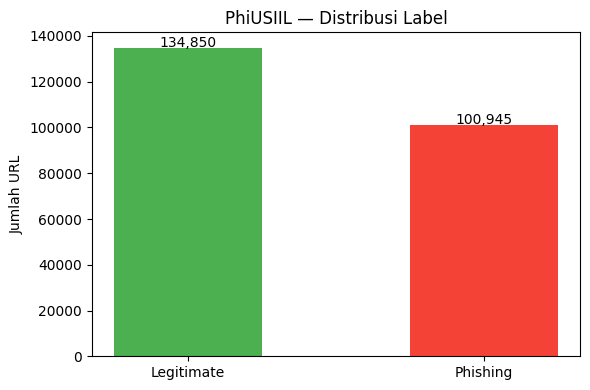

In [8]:
# Visualisasi distribusi label PhiUSIIL
fig, ax = plt.subplots(figsize=(6, 4))

label_map_phi = {1: 'Legitimate', 0: 'Phishing'}
phi_counts = df_phi['label'].map(label_map_phi).value_counts()
bars = ax.bar(phi_counts.index, phi_counts.values, color=['#4CAF50', '#F44336'], width=0.5)
ax.set_title('PhiUSIIL — Distribusi Label')
ax.set_ylabel('Jumlah URL')
for i, v in enumerate(phi_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=120, bbox_inches='tight')
plt.show()

### Menghapus data yang duplikat

In [9]:
# PhiUSIIL
sebelum_phi = len(df_phi)
url_col_phi = 'URL'
df_phi = df_phi.drop_duplicates(subset=[url_col_phi], keep='first')
df_phi = df_phi.reset_index(drop=True)
print(f'PhiUSIIL — Sebelum: {sebelum_phi:,} | Setelah: {len(df_phi):,} | '
      f'Duplikat dihapus: {sebelum_phi - len(df_phi):,}')

PhiUSIIL — Sebelum: 235,795 | Setelah: 235,370 | Duplikat dihapus: 425


### Menangani missing values

In [10]:
def tangani_missing(df, nama, threshold=0.40):
    print(f'\n=== {nama} ===')
    missing_pct = df.isnull().mean()

    kolom_hapus = missing_pct[missing_pct > threshold].index.tolist()
    if kolom_hapus:
        df = df.drop(columns=kolom_hapus)
        print(f'Kolom dihapus (missing >{threshold*100:.0f}%): {kolom_hapus}')
    else:
        print(f'Tidak ada kolom dengan missing >{threshold*100:.0f}%')

    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f'  [{col}] diisi dengan median: {median_val:.4f}')
            else:
                modus_val = df[col].mode()[0]
                df[col] = df[col].fillna(modus_val)
                print(f'  [{col}] diisi dengan modus: {modus_val}')

    total_missing_sisa = df.isnull().sum().sum()
    print(f'Total missing setelah cleaning: {total_missing_sisa}')
    return df

df_phi = tangani_missing(df_phi, 'PhiUSIIL')


=== PhiUSIIL ===
Tidak ada kolom dengan missing >40%
Total missing setelah cleaning: 0


### Valiidasi dan normalisasi  format

In [11]:
def validasi_url(url):
    """Return True jika URL valid, False jika tidak."""
    if not isinstance(url, str):
        return False
    url = url.strip()
    if len(url) < 5 or len(url) > 2000:
        return False
    if '.' not in url:
        return False
    pattern = re.compile(
        r'^(https?://)'
        r'[\w\-]+(\.[\w\-]+)+'
        r'(/[^\s]*)?$',
        re.IGNORECASE
    )
    return bool(pattern.match(url))

def bersihkan_url(df, url_col):
    sebelum = len(df)
    df[url_col] = df[url_col].astype(str).str.strip().str.lower()
    mask_valid = df[url_col].apply(validasi_url)
    df = df[mask_valid].reset_index(drop=True)
    sesudah = len(df)
    print(f'URL tidak valid : {sebelum - sesudah:,} baris')
    print(f'Sisa data       : {sesudah:,} baris')
    return df

print('=== PhiUSIIL ===')
df_phi = bersihkan_url(df_phi, url_col_phi)

=== PhiUSIIL ===
URL tidak valid : 51 baris
Sisa data       : 235,319 baris


### Normalisasi label

In [12]:
# PhiUSIIL: flip label agar konsisten (1=Phishing, 0=Legitimate)
# di dataset asli: label=1 adalah Legitimate, label=0 adalah Phishing
df_phi['label'] = df_phi['label'].map({1: 0, 0: 1})
print('PhiUSIIL — Distribusi label setelah normalisasi:')
print(df_phi['label'].value_counts().rename({0: 'Legitimate (0)', 1: 'Phishing (1)'}))

PhiUSIIL — Distribusi label setelah normalisasi:
label
Legitimate (0)    134850
Phishing (1)      100469
Name: count, dtype: int64


### Mendeteksi dan menangani outlier (PhiUSIIL)

In [13]:
import numpy as np

print('--- DETEKSI DATA MUSTAHIL (NOISE LOGIKA) ---')

kolom_exclude = ['URL', 'label']
fitur_numerik_phi = [c for c in df_phi.select_dtypes(include=[np.number]).columns
                     if c not in kolom_exclude]

def cek_dan_hapus_noise(df, nama_df, fitur_numerik):
    ada_error = False
    for col in fitur_numerik:
        if any(kata in col.lower() for kata in ['length', 'len', 'count', 'noof']):
            jumlah_negatif = (df[col] < 0).sum()
            if jumlah_negatif > 0:
                print(f'[{nama_df}] ERROR: {jumlah_negatif} nilai negatif pada kolom "{col}"')
                ada_error = True
        if 'ratio' in col.lower() or 'prob' in col.lower():
            jumlah_mustahil = ((df[col] < 0) | (df[col] > 1)).sum()
            if jumlah_mustahil > 0:
                print(f'[{nama_df}] ERROR: {jumlah_mustahil} rasio/prob mustahil pada "{col}"')
                ada_error = True
    if ada_error:
        ukuran_awal = len(df)
        for col in fitur_numerik:
            if any(kata in col.lower() for kata in ['length', 'len', 'count', 'noof']):
                df = df[df[col] >= 0]
            if 'ratio' in col.lower() or 'prob' in col.lower():
                df = df[(df[col] >= 0) & (df[col] <= 1)]
        print(f'[{nama_df}] Pembersihan selesai: {ukuran_awal - len(df)} baris dihapus.')
    else:
        print(f'[{nama_df}] DATA AMAN — Tidak ada noise logika yang ditemukan.')
    return df

df_phi = cek_dan_hapus_noise(df_phi, 'PhiUSIIL', fitur_numerik_phi)
print(f'\nShape setelah noise check: {df_phi.shape}')

--- DETEKSI DATA MUSTAHIL (NOISE LOGIKA) ---
[PhiUSIIL] DATA AMAN — Tidak ada noise logika yang ditemukan.

Shape setelah noise check: (235319, 55)


### Feature selection (PhiUSIIL)

In [14]:
# fitur yang dalam bentuk URL aja
FITUR_URL_ONLY = [
    # struktur URL
    'URLLength',
    'DomainLength',         # panjang domain
    'IsDomainIP',           # apakah domain berupa IP address
    'URLSimilarityIndex',   # skor kemiripan URL dengan domain asli
    'CharContinuationRate', # rasio karakter berulang
    'TLDLegitimateProb',    # probabilitas TLD legitimate
    'URLCharProb',          # probabilitas karakter URL
    'TLDLength',            # panjang TLD
    'NoOfSubDomain',        # jumlah subdomain
    'HasObfuscation',       # ada obfuskasi?
    'NoOfObfuscatedChar',   # jumlah karakter terobfuskasi
    'ObfuscationRatio',     # rasio obfuskasi
    # karakter khusus
    'NoOfLettersInURL',     # jumlah huruf
    'LetterRatioInURL',     # rasio huruf
    'NoOfDegitsInURL',      # jumlah digit
    'DegitRatioInURL',      # rasio digit
    'NoOfEqualsInURL',      # jumlah tanda '='
    'NoOfQMarkInURL',       # jumlah tanda '?'
    'NoOfAmpersandInURL',   # jumlah tanda '&'
    'NoOfOtherSpecialCharsInURL',  # jumlah karakter khusus lain
    'SpacialCharRatioInURL',       # rasio karakter khusus
    # HTTPS dan keamanan
    'IsHTTPS',              # menggunakan HTTPS?
    'HasSocialNet',         # ada nama social network di URL?
    'HasCopyrightInfo',     # ada kata copyright?
    'HasDescription',       # ada deskripsi?
    # label
    'label'
]

# filter agar hanya kolom yang tersedia di dataset
fitur_tersedia = [f for f in FITUR_URL_ONLY if f in df_phi.columns]
fitur_tidak_ada = [f for f in FITUR_URL_ONLY if f not in df_phi.columns]
print(f'Fitur dipilih  : {len(fitur_tersedia)}')
print(f'Fitur tidak ada di dataset: {fitur_tidak_ada}')
df_phi_selected = df_phi[[url_col_phi] + fitur_tersedia].copy()
print(f'\nShape setelah feature selection: {df_phi_selected.shape}')

Fitur dipilih  : 26
Fitur tidak ada di dataset: []

Shape setelah feature selection: (235319, 27)


Kolom dihapus karena korelasi tinggi: ['NoOfLettersInURL']
Shape akhir: (235319, 26)


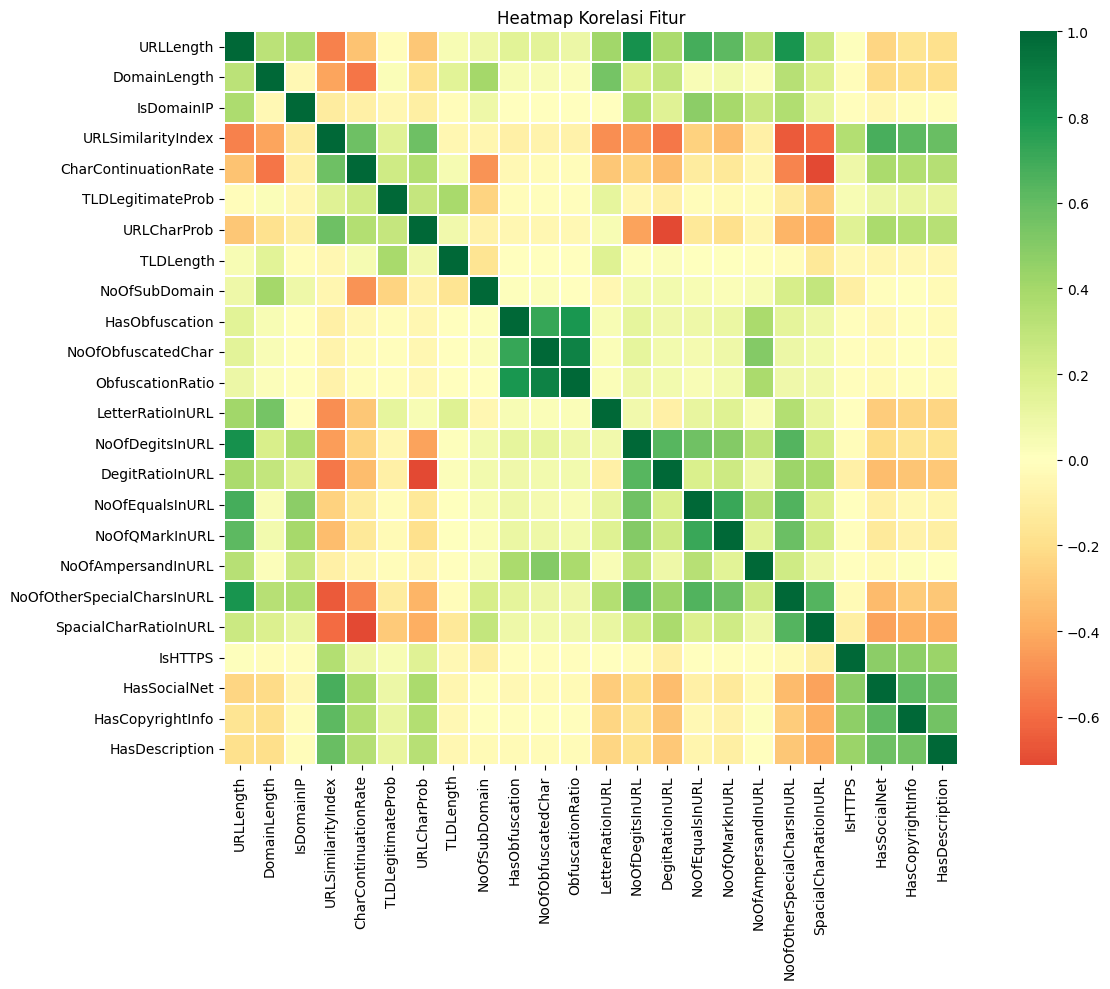

In [15]:
# cek hubungan antar fitur
X_temp = df_phi_selected.drop(columns=[url_col_phi, 'label'], errors='ignore')
corr_matrix = X_temp.corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# menghapus kolom dengan korelasi > 95% dengan kolom lainnya
kolom_drop_korelasi = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]
if kolom_drop_korelasi:
    df_phi_selected = df_phi_selected.drop(columns=kolom_drop_korelasi)
    print(f'Kolom dihapus karena korelasi tinggi: {kolom_drop_korelasi}')
else:
    print('Tidak ada kolom dengan korelasi >0.95')
print(f'Shape akhir: {df_phi_selected.shape}')

# heatmap korelasi
plt.figure(figsize=(14, 10))
fitur_plot = [c for c in df_phi_selected.columns if c not in [url_col_phi, 'label']]
sns.heatmap(
    df_phi_selected[fitur_plot].corr(),
    cmap='RdYlGn', center=0, annot=False,
    square=True, linewidths=0.3
)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=120, bbox_inches='tight')
plt.show()

### Menanggani class imbalance dengan SMOTE

Distribusi sebelum SMOTE: Counter({np.int64(0): 134850, np.int64(1): 100469})
Distribusi setelah SMOTE : Counter({np.int64(0): 134850, np.int64(1): 134850})
Shape X setelah SMOTE    : (269700, 24)

 === Visualisasi Perbandingan ===


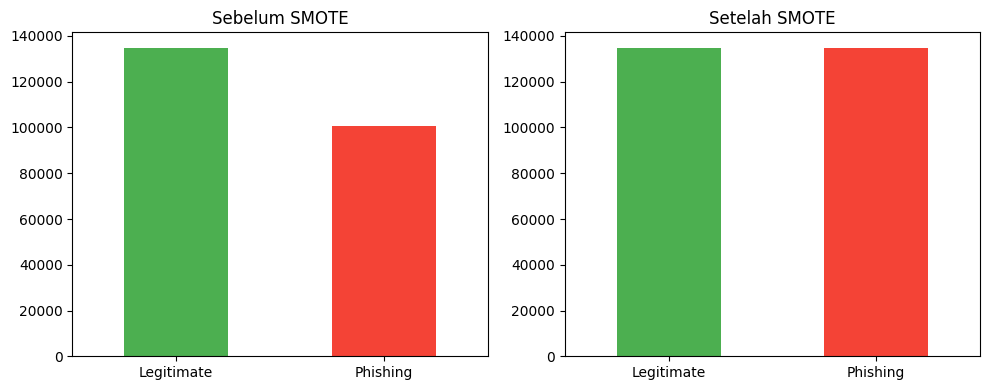

In [16]:
from imblearn.over_sampling import SMOTE

# memisahkan fitur dan label
fitur_model = [c for c in df_phi_selected.columns
               if c not in [url_col_phi, 'label']]
X = df_phi_selected[fitur_model].values
y = df_phi_selected['label'].values
print(f'Distribusi sebelum SMOTE: {Counter(y)}')

# menerapkan SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f'Distribusi setelah SMOTE : {Counter(y_resampled)}')
print(f'Shape X setelah SMOTE    : {X_resampled.shape}')

# menyimpan kembali nilai baru ke dalam dataframe
df_train_balanced = pd.DataFrame(X_resampled, columns=fitur_model)
df_train_balanced['label'] = y_resampled

# membandingkan sebelum dan sesudah SMOTE dengan visualisasi
print("\n === Visualisasi Perbandingan ===")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y).value_counts().plot(kind='bar', ax=axes[0],
    color=['#4CAF50','#F44336'], title='Sebelum SMOTE')
pd.Series(y_resampled).value_counts().plot(kind='bar', ax=axes[1],
    color=['#4CAF50','#F44336'], title='Setelah SMOTE')
axes[0].set_xticklabels(['Legitimate','Phishing'], rotation=0)
axes[1].set_xticklabels(['Legitimate','Phishing'], rotation=0)
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()

### Normalisasi fitur menggunakan MinMaxScaler

In [17]:
from sklearn.preprocessing import MinMaxScaler
import joblib

fitur_scale = [c for c in df_train_balanced.columns if c != 'label']

scaler = MinMaxScaler()
df_train_balanced[fitur_scale] = scaler.fit_transform(
    df_train_balanced[fitur_scale]
)

# menyimpan scaler agar dapat dipakai saat inferensi di API Flask
joblib.dump(scaler, 'scaler_epiccsafe.pkl')
print('Scaler disimpan: scaler_epiccsafe.pkl')
print(f'\nContoh nilai setelah scaling:')
print(df_train_balanced[fitur_scale[:5]].describe().round(4))

Scaler disimpan: scaler_epiccsafe.pkl

Contoh nilai setelah scaling:
         URLLength  DomainLength   IsDomainIP  URLSimilarityIndex  \
count  269700.0000   269700.0000  269700.0000         269700.0000   
mean        0.0130        0.1684       0.0032              0.7468   
std         0.0194        0.0908       0.0563              0.2997   
min         0.0000        0.0000       0.0000              0.0000   
25%         0.0063        0.1132       0.0000              0.5121   
50%         0.0085        0.1509       0.0000              1.0000   
75%         0.0125        0.1981       0.0000              1.0000   
max         1.0000        1.0000       1.0000              1.0000   

       CharContinuationRate  
count           269700.0000  
mean                 0.8309  
std                  0.2228  
min                  0.0000  
25%                  0.6562  
50%                  1.0000  
75%                  1.0000  
max                  1.0000  


### Menyimpan dataset yang sudah bersih

In [18]:
# menyimpan data yang sudah bersih
df_train_balanced.to_csv('train_cleaned.csv', index=False)
print(f'Simpan: train_cleaned.csv  — {df_train_balanced.shape}')

# menyimpan daftar nama fitur yang digunakan model
import json as _json
with open('fitur_model.json', 'w') as f:
    _json.dump(fitur_model, f)
print('Simpan: fitur_model.json')

print('\n' + '='*55)
print('HASIL DATA CLEANING')
print('='*55)
print(f'Dataset PhiUSIIL setelah cleaning + SMOTE:')
print(f'  Total baris  : {len(df_train_balanced):,}')
print(f'  Jumlah fitur : {df_train_balanced.shape[1]-1}')
print(f'  Legitimate   : {(df_train_balanced.label==0).sum():,}')
print(f'  Phishing     : {(df_train_balanced.label==1).sum():,}')
print('='*55)
print('\nFile output:')
print('  train_cleaned.csv')
print('  scaler_epiccsafe.pkl')
print('  fitur_model.json')
print('\nData cleaning selesai ✅')

Simpan: train_cleaned.csv  — (269700, 25)
Simpan: fitur_model.json

HASIL DATA CLEANING
Dataset PhiUSIIL setelah cleaning + SMOTE:
  Total baris  : 269,700
  Jumlah fitur : 24
  Legitimate   : 134,850
  Phishing     : 134,850

File output:
  train_cleaned.csv
  scaler_epiccsafe.pkl
  fitur_model.json

Data cleaning selesai ✅


## Model Training

### Train test split

In [19]:
from sklearn.model_selection import train_test_split

# load data PhiUSIIL yang sudah bersih
df_train = pd.read_csv('train_cleaned.csv')

# memisahkan fitur dan label
X = df_train.drop(columns=['label'])
y = df_train['label']

print('Shape data sebelum split:')
print(f'  X : {X.shape}')
print(f'  y : {y.shape}')
print(f'  Distribusi label: {dict(y.value_counts())}')

# split 80% train, 20% test — stratified agar proporsi phishing sama
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('\nHasil Split (80:20 stratified):')
print(f'  X_train : {X_train.shape}  — {len(X_train):,} baris')
print(f'  X_test  : {X_test.shape}   — {len(X_test):,} baris')
print(f'\nDistribusi label di X_train:')
print(f'  Legitimate (0) : {(y_train==0).sum():,}')
print(f'  Phishing   (1) : {(y_train==1).sum():,}')
print(f'\nDistribusi label di X_test:')
print(f'  Legitimate (0) : {(y_test==0).sum():,}')
print(f'  Phishing   (1) : {(y_test==1).sum():,}')

print('\n' + '='*50)
print('HASIL SPLIT')
print('='*50)
print(f'  X_train : {len(X_train):,} baris  → melatih model')
print(f'  X_test  : {len(X_test):,} baris   → evaluasi final')
print('  Sumber  : PhiUSIIL (1 dataset, split stratified)')
print('='*50)

Shape data sebelum split:
  X : (269700, 24)
  y : (269700,)
  Distribusi label: {0: np.int64(134850), 1: np.int64(134850)}

Hasil Split (80:20 stratified):
  X_train : (215760, 24)  — 215,760 baris
  X_test  : (53940, 24)   — 53,940 baris

Distribusi label di X_train:
  Legitimate (0) : 107,880
  Phishing   (1) : 107,880

Distribusi label di X_test:
  Legitimate (0) : 26,970
  Phishing   (1) : 26,970

HASIL SPLIT
  X_train : 215,760 baris  → melatih model
  X_test  : 53,940 baris   → evaluasi final
  Sumber  : PhiUSIIL (1 dataset, split stratified)


### Training model

TRAINING & EVALUASI MODEL
Data train : PhiUSIIL 80%
Data test  : PhiUSIIL 20% (stratified split)

[Random Forest]
  Waktu training : 28.8s
  Accuracy       : 0.9999
  Precision      : 1.0000
  Recall         : 0.9998
  F1-Score       : 0.9999
  ROC-AUC        : 1.0000

[Gradient Boosting]
  Waktu training : 127.4s
  Accuracy       : 0.9999
  Precision      : 1.0000
  Recall         : 0.9998
  F1-Score       : 0.9999
  ROC-AUC        : 1.0000

[Logistic Regression]
  Waktu training : 2.4s
  Accuracy       : 0.9996
  Precision      : 1.0000
  Recall         : 0.9991
  F1-Score       : 0.9996
  ROC-AUC        : 1.0000

PERBANDINGAN MODEL
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          0.9999        1.0  0.9998    0.9999      1.0
Gradient Boosting      0.9999        1.0  0.9998    0.9999      1.0
Logistic Regression    0.9996        1.0  0.9991    0.9996      1.0

✅ Model terpilih : Random Forest
   F1-Score       : 0.9999

Model disimpan : model_

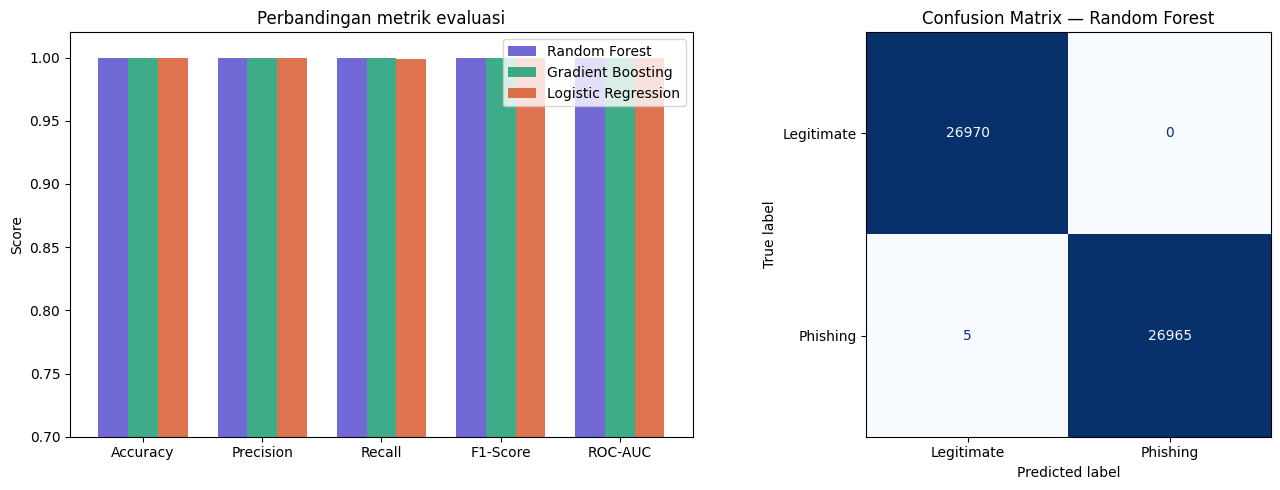

Plot disimpan: training_results.png


In [20]:
import joblib
import time
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# perbandingan model
kandidat_model = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_leaf=2,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1
    )
}

# training dan testing dari x_test 20%
print('='*60)
print('TRAINING & EVALUASI MODEL')
print('Data train : PhiUSIIL 80%')
print('Data test  : PhiUSIIL 20% (stratified split)')
print('='*60)

hasil_eval = {}
model_objects = {}

for nama, model in kandidat_model.items():
    print(f'\n[{nama}]')
    t0 = time.time()
    model.fit(X_train, y_train)
    durasi = time.time() - t0

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    hasil_eval[nama] = {
        'Accuracy' : acc, 'Precision': prec,
        'Recall'   : rec, 'F1-Score' : f1, 'ROC-AUC'  : auc
    }
    model_objects[nama] = model

    print(f'  Waktu training : {durasi:.1f}s')
    print(f'  Accuracy       : {acc:.4f}')
    print(f'  Precision      : {prec:.4f}')
    print(f'  Recall         : {rec:.4f}')
    print(f'  F1-Score       : {f1:.4f}')
    print(f'  ROC-AUC        : {auc:.4f}')

# memilih model terbaik berdasarkan f1-score
df_hasil = pd.DataFrame(hasil_eval).T.sort_values('F1-Score', ascending=False)
print('\n' + '='*60)
print('PERBANDINGAN MODEL')
print('='*60)
print(df_hasil.round(4).to_string())

nama_terbaik   = df_hasil.index[0]
model_terbaik  = model_objects[nama_terbaik]
print(f'\n✅ Model terpilih : {nama_terbaik}')
print(f'   F1-Score       : {df_hasil.loc[nama_terbaik, "F1-Score"]:.4f}')

# menyimpan model terbaik
joblib.dump(model_terbaik, 'model_epiccsafe.pkl')
print(f'\nModel disimpan : model_epiccsafe.pkl')

# visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrik = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x      = range(len(metrik))
width  = 0.25
colors = ['#5B4FCF', '#1D9E75', '#D85A30']

for idx, (nama, vals) in enumerate(hasil_eval.items()):
    offset = (idx - 1) * width
    axes[0].bar(
        [xi + offset for xi in x],
        [vals[m] for m in metrik],
        width, label=nama, color=colors[idx], alpha=0.85
    )
axes[0].set_title('Perbandingan metrik evaluasi')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(metrik)
axes[0].set_ylim(0.7, 1.02)
axes[0].legend()
axes[0].set_ylabel('Score')

y_pred_best = model_terbaik.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing']).plot(
    ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title(f'Confusion Matrix — {nama_terbaik}')

plt.tight_layout()
plt.savefig('training_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot disimpan: training_results.png')

## Risk Scoring

### Evaluasi

RISK SCORING — TEST SET (PhiUSIIL 20%)

Distribusi risk score per kelas aktual:
                count   mean   std   min    25%    50%     75%     max
label_actual                                                          
0             26970.0   0.11  0.63  0.00    0.0    0.0    0.02   19.65
1             26970.0  99.87  1.56  0.98  100.0  100.0  100.00  100.00

Contoh 6 prediksi acak dari dataset:
URL       : https://www.burleighphoto.com
Risk Score:   0.00 | Aktual: Legitimate | RENDAH   — URL aman, tidak ada notifikasi
URL       : https://www.lunchoverip.com
Risk Score:   0.05 | Aktual: Legitimate | RENDAH   — URL aman, tidak ada notifikasi
URL       : http://osturah.com
Risk Score: 100.00 | Aktual: Phishing  | TINGGI   — Pop-up merah, warning keras (high risk), user disarankan tidak melanjutkan
URL       : http://www.underneathstardoll.com
Risk Score: 100.00 | Aktual: Phishing  | TINGGI   — Pop-up merah, warning keras (high risk), user disarankan tidak melanjutkan
URL       : https

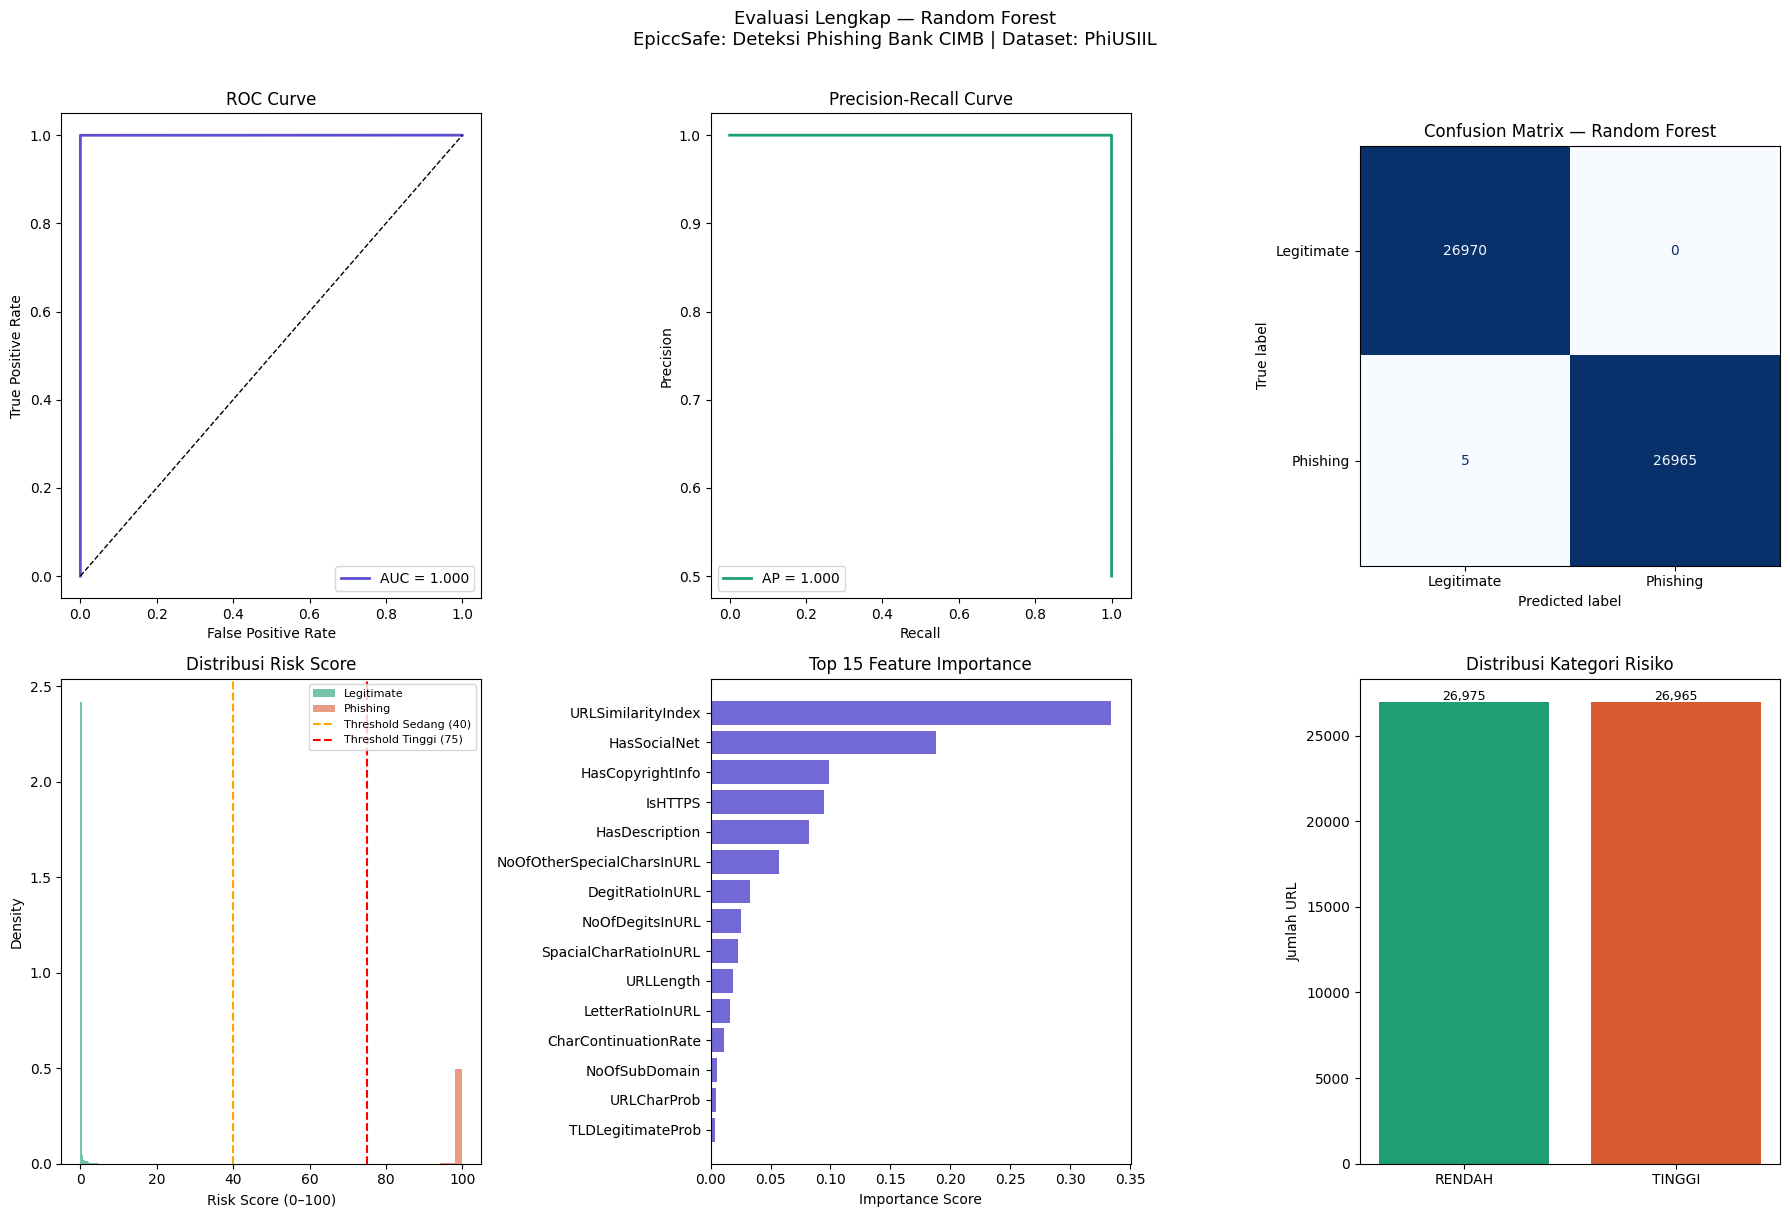

Plot disimpan: evaluasi_lengkap.png

SISTEM EPICCSAFE
Model final    : Random Forest
File model     : model_epiccsafe.pkl
File scaler    : scaler_epiccsafe.pkl
File fitur     : fitur_model.json
Accuracy       : 0.9999
F1-Score       : 0.9999
ROC-AUC        : 1.0000

Threshold risk score sistem EpiccSafe:
  0  – 30  → RENDAH  : URL aman, tidak ada notifikasi
  31 – 70  → SEDANG  : Pop-up kuning, user diperingatkan
  71 – 100 → TINGGI  : Pop-up merah, warning keras (high risk), user disarankan tidak melanjutkan
Evaluasi selesai ✅


In [32]:
from sklearn.metrics import (
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)

# Risk scoring

def hitung_risk_score(prob_phishing):
    """Konversi probabilitas model menjadi risk score 0–100."""
    return round(float(prob_phishing) * 100, 2)

def klasifikasi_risiko(score):
    """Tentukan kategori dan tindakan sistem berdasarkan risk score."""
    if score >= 71:
        return 'TINGGI   — Pop-up merah, warning keras (high risk), user disarankan tidak melanjutkan'
    elif score >= 31:
        return 'SEDANG   — Pop-up kuning, user diperingatkan'
    else:
        return 'RENDAH   — URL aman, tidak ada notifikasi'

#  hitung risk score di test set
print('='*62)
print('RISK SCORING — TEST SET (PhiUSIIL 20%)')
print('='*62)

y_prob_test   = model_terbaik.predict_proba(X_test)[:, 1]
risk_scores   = [hitung_risk_score(p) for p in y_prob_test]

df_risk = pd.DataFrame({
    'risk_score'   : risk_scores,
    'label_actual' : y_test.values,
    'pred_label'   : model_terbaik.predict(X_test)
})
df_risk['kategori'] = df_risk['risk_score'].apply(klasifikasi_risiko)

print('\nDistribusi risk score per kelas aktual:')
print(df_risk.groupby('label_actual')['risk_score'].describe().round(2))

print('\nContoh 6 prediksi acak dari dataset:')

# 1. Ambil 6 data acak dari dataframe asli (sebelum SMOTE) agar URL-nya nyata
sample = df_phi_selected.sample(6)

# 2. Siapkan fiturnya lalu lakukan scaling (menggunakan scaler yang sudah di-fit)
X_demo = sample[fitur_model]
X_demo_scaled = scaler.transform(X_demo)

# 3. Lakukan prediksi probabilitas
prob_demo = model_terbaik.predict_proba(X_demo_scaled)[:, 1]

# 4. Tampilkan hasilnya beserta URL
for i, (idx, row) in enumerate(sample.iterrows()):
    url_demo = row[url_col_phi] # Mengambil string URL
    actual_label = row['label']
    actual = 'Phishing ' if actual_label == 1 else 'Legitimate'
    r_score = hitung_risk_score(prob_demo[i])
    kategori = klasifikasi_risiko(r_score)

    print(f'URL       : {url_demo}')
    print(f'Risk Score: {r_score:6.2f} | Aktual: {actual} | {kategori}')

# Evaluasi final
print('\n' + '='*62)
print('EVALUASI FINAL — TEST SET (PhiUSIIL 20%)')
print(f'Model : {nama_terbaik}')
print('='*62)

y_pred_test = model_terbaik.predict(X_test)

acc_f  = accuracy_score(y_test, y_pred_test)
prec_f = precision_score(y_test, y_pred_test)
rec_f  = recall_score(y_test, y_pred_test)
f1_f   = f1_score(y_test, y_pred_test)
auc_f  = roc_auc_score(y_test, y_prob_test)

print(f'  Accuracy  : {acc_f:.4f}')
print(f'  Precision : {prec_f:.4f}')
print(f'  Recall    : {rec_f:.4f}')
print(f'  F1-Score  : {f1_f:.4f}')
print(f'  ROC-AUC   : {auc_f:.4f}')

print('\nClassification Report:')
print(classification_report(
    y_test, y_pred_test,
    target_names=['Legitimate (0)', 'Phishing (1)']
))

# Visualisasi
fig = plt.figure(figsize=(18, 12))

# (1) ROC
ax1 = fig.add_subplot(2, 3, 1)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
ax1.plot(fpr, tpr, color='#5B4FCF', lw=2, label=f'AUC = {auc_f:.3f}')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

# (2) Precision-Recall
ax2 = fig.add_subplot(2, 3, 2)
prec_r, rec_r, _ = precision_recall_curve(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)
ax2.plot(rec_r, prec_r, color='#1D9E75', lw=2, label=f'AP = {ap:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

# (3) Confusion Matrix
ax3 = fig.add_subplot(2, 3, 3)
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing']).plot(
    ax=ax3, cmap='Blues', colorbar=False
)
ax3.set_title(f'Confusion Matrix — {nama_terbaik}')

# (4) Distribusi Risk Score
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist(df_risk[df_risk['label_actual'] == 0]['risk_score'],
         bins=50, alpha=0.6, color='#1D9E75', label='Legitimate', density=True)
ax4.hist(df_risk[df_risk['label_actual'] == 1]['risk_score'],
         bins=50, alpha=0.6, color='#D85A30', label='Phishing', density=True)
ax4.axvline(x=40, color='orange', linestyle='--', lw=1.5, label='Threshold Sedang (40)')
ax4.axvline(x=75, color='red',    linestyle='--', lw=1.5, label='Threshold Tinggi (75)')
ax4.set_xlabel('Risk Score (0–100)')
ax4.set_ylabel('Density')
ax4.set_title('Distribusi Risk Score')
ax4.legend(fontsize=8)

# (5) Feature Importance
ax5 = fig.add_subplot(2, 3, 5)
if hasattr(model_terbaik, 'feature_importances_'):
    importances = model_terbaik.feature_importances_
    fitur_names = X_train.columns.tolist()
    idx_sorted  = np.argsort(importances)[::-1][:15]
    ax5.barh(
        [fitur_names[i] for i in idx_sorted][::-1],
        importances[idx_sorted][::-1],
        color='#5B4FCF', alpha=0.85
    )
    ax5.set_title('Top 15 Feature Importance')
    ax5.set_xlabel('Importance Score')
elif hasattr(model_terbaik, 'coef_'):
    coef = np.abs(model_terbaik.coef_[0])
    fitur_names = X_train.columns.tolist()
    idx_sorted  = np.argsort(coef)[::-1][:15]
    ax5.barh(
        [fitur_names[i] for i in idx_sorted][::-1],
        coef[idx_sorted][::-1],
        color='#5B4FCF', alpha=0.85
    )
    ax5.set_title('Top 15 Koefisien Fitur')
    ax5.set_xlabel('|Coefficient|')
else:
    ax5.text(0.5, 0.5, 'Feature importance\ntidak tersedia',
             ha='center', va='center', transform=ax5.transAxes)

# (6) Distribusi risk score per kategori (pie-like bar)
ax6 = fig.add_subplot(2, 3, 6)
kategori_counts = df_risk['kategori'].apply(
    lambda x: 'TINGGI' if 'TINGGI' in x else ('SEDANG' if 'SEDANG' in x else 'RENDAH')
).value_counts()
colors_pie = {'RENDAH': '#1D9E75', 'SEDANG': '#EF9F27', 'TINGGI': '#D85A30'}
ax6.bar(
    kategori_counts.index,
    kategori_counts.values,
    color=[colors_pie.get(k, '#888') for k in kategori_counts.index]
)
for i, v in enumerate(kategori_counts.values):
    ax6.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)
ax6.set_title('Distribusi Kategori Risiko')
ax6.set_ylabel('Jumlah URL')

plt.suptitle(
    f'Evaluasi Lengkap — {nama_terbaik}\n'
    f'EpiccSafe: Deteksi Phishing Bank CIMB | Dataset: PhiUSIIL',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('evaluasi_lengkap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot disimpan: evaluasi_lengkap.png')

# Ringkasan
print('\n' + '='*62)
print('SISTEM EPICCSAFE')
print('='*62)
print(f'Model final    : {nama_terbaik}')
print(f'File model     : model_epiccsafe.pkl')
print(f'File scaler    : scaler_epiccsafe.pkl')
print(f'File fitur     : fitur_model.json')
print(f'Accuracy       : {acc_f:.4f}')
print(f'F1-Score       : {f1_f:.4f}')
print(f'ROC-AUC        : {auc_f:.4f}')
print('\nThreshold risk score sistem EpiccSafe:')
print('  0  – 30  → RENDAH  : URL aman, tidak ada notifikasi')
print('  31 – 70  → SEDANG  : Pop-up kuning, user diperingatkan')
print('  71 – 100 → TINGGI  : Pop-up merah, warning keras (high risk), user disarankan tidak melanjutkan')
print('='*62)
print('Evaluasi selesai ✅')